<a href="https://colab.research.google.com/github/adljna/ProjectA-Group3-KematianAliKhamenei/blob/main/Content%20Scrapping%20%26%20Preprocessing/Tribunnews/2_Tribunnews_Scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing Indonesian Text

**(1) Instalasi Library**

Bagian ini berisi instalasi semua library Python yang dibutuhkan untuk scraping, preprocessing teks, POS tagging, dan analisis sentimen.

In [ ]:
# Library untuk scraping dan manipulasi data
!pip install beautifulsoup4 requests pandas

# Library untuk NLP: polyglot (untuk deteksi bahasa), deep-translator (untuk terjemahan), Sastrawi (untuk stemming), Stanza (untuk POS Tagging)
!pip install polyglot icu pycld2 pyicu morfessor
!pip install deep-translator
!pip install Sastrawi
!pip install stanza

# Library tambahan untuk NLP (NLTK) dan visualisasi (wordcloud)
!pip install nltk
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.3/126.3 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.2/268.2 kB 15.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 58.7 MB/s eta 0:00:00
  Created wheel for polyglot: filename=polyglot-16.7.4-py2.py3-none-any.whl size=52563 sha256=711b0162ae1a2c3c55c02874ce41ba9bd3108f778eb2b7e0d7d31503ec52044b
  Stored in directory: /root/.cache/pip/wheels/c7/5e/28/47349211ec1f91379f41ed10bc2520f7071ecfb6cbe182f6fe
  Created wheel for pyicu: filename=pyicu-2.16.2-cp312-cp312-linux_x86_64.whl size=2720234 sha256=db9e97c1ab402c997b0cd7bfcffe2e3c22ffb0a2c21f2c88378996c8b1f3a727
  Stored in directory: /root/.cache/pip/wheels/25/f3/cd/4923c874cedf8cdb860803

**(2) Impor Library**

Bagian ini mengimpor semua modul dan fungsi yang diperlukan dari library yang telah diinstal. Import dikelompokkan berdasarkan fungsinya.

In [13]:
# Standard Library
import io
import string
import re
import time
from collections import defaultdict, Counter

# Data Handling
import pandas as pd
import numpy as np

# Web Scraping
import requests
from bs4 import BeautifulSoup
from google.colab import files

# Natural Language Processing (NLP) - NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

# Natural Language Processing (NLP) - Sastrawi (Stemming)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Natural Language Processing (NLP) - Stanza (POS Tagging)
import stanza

# Natural Language Processing (NLP) - Polyglot (Language Detection)
# from polyglot.text import Text

# Sentiment Analysis
from textblob import TextBlob
from deep_translator import GoogleTranslator

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
# Download NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**(3) Data Scraping**

Bagian ini bertanggung jawab untuk mengunggah file CSV yang berisi tautan (links) dan melakukan scraping konten artikel dari tautan tersebut. Menggunakan `requests` dan `BeautifulSoup`.

In [5]:
from google.colab import files

# Upload the CSV file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Saving Tugas 1A Kelompok 3 - Sheet8 (1).csv to Tugas 1A Kelompok 3 - Sheet8 (1) (1).csv


In [6]:
import io
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time # Import time for adding delays
import random # Import random for randomized delays

try:
    # Modified: Changed from pd.read_excel to pd.read_csv and removed sheet_name
    links_df = pd.read_csv(io.BytesIO(uploaded[filename]))

    if 'Link' in links_df.columns:
        urls = links_df['Link'].tolist()
        print(f"Successfully loaded {len(urls)} URLs from '{filename}'.")
    else:
        print("Error: 'link' column not found in the uploaded file. Please check your CSV file.")
        urls = [] # Set urls to empty if column not found
except FileNotFoundError:
    print("Error: Uploaded file not found. Please upload the CSV file.")
    urls = [] # Set urls to empty if file not found
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
    urls = []
# --------------------------------------------------

# Function to scrape content from a URL with retries
def scrape_content(url, max_retries=3, initial_delay=2): # Increased initial_delay for retries
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36'}
    for attempt in range(max_retries):
        try:
            response = requests.get(url, headers=headers, timeout=15)
            if response.status_code == 200:
                soup = BeautifulSoup(response.content, 'html.parser')

                # Extract the title of the article
                title = 'No Title Found'
                title_tag = soup.find('h1', class_='f24') or soup.find('h1') or soup.find('title')
                if title_tag:
                    title = title_tag.text.strip()

                # Extract the article's content
                article_content_div = soup.find('div', class_='side-article txt-article multi-fontsize') or \
                                      soup.find('article') or \
                                      soup.find('div', class_='article-content') or \
                                      soup.find('div', class_='detail_text')

                paragraphs = []
                if article_content_div:
                    paragraphs = article_content_div.find_all('p')
                else:
                    paragraphs = soup.find_all('p')

                # Filter out short paragraphs and common non-content text including ad phrases
                filtered_paragraphs = [p.text.strip() for p in paragraphs
                                       if p.text.strip() and
                                       len(p.text.strip()) > 30 and
                                       not p.text.strip().lower().startswith(("baca:", "tonton:", "video:", "tribun-video.com", "(*) ", "download tribunx untuk android & ios")) and
                                       not "download tribunx untuk android & ios" in p.text.strip().lower() # Also check if phrase is in middle
                                      ]

                content = "\n".join(filtered_paragraphs)

                if not content and paragraphs: # If filtering removed everything, try a less strict approach
                     content = "\n".join([p.text.strip() for p in paragraphs if p.text.strip()])

                return {
                    "url": url,
                    "title": title,
                    "content": content
                }

            elif response.status_code == 403: # Forbidden, might be temporary or due to rate limiting
                print(f"  Attempt {attempt + 1}: Received 403 Forbidden for {url}. Retrying after {initial_delay * (attempt + 1)} seconds...")
                time.sleep(initial_delay * (attempt + 1) + random.uniform(0.5, 1.5)) # Exponential backoff + random jitter
                continue
            else:
                return {
                    "url": url,
                    "title": None,
                    "content": None,
                    "error": f"Failed to fetch page, status code: {response.status_code}"
                }
        except requests.exceptions.Timeout:
            print(f"  Attempt {attempt + 1}: Request timed out for {url}. Retrying after {initial_delay * (attempt + 1)} seconds...")
            time.sleep(initial_delay * (attempt + 1) + random.uniform(0.5, 1.5))
            continue
        except requests.exceptions.RequestException as req_err:
            print(f"  Attempt {attempt + 1}: Request failed for {url}: {req_err}. Retrying after {initial_delay * (attempt + 1)} seconds...")
            time.sleep(initial_delay * (attempt + 1) + random.uniform(0.5, 1.5))
            continue
        except Exception as e:
            return {
                "url": url,
                "title": None,
                "content": None,
                "error": str(e)
            }
    # If all retries fail
    return {
        "url": url,
        "title": None,
        "content": None,
        "error": f"All {max_retries} attempts failed after multiple retries."
    }

# Scrape each URL and store the results in a list of dictionaries
data = []
if urls:
    for i, url in enumerate(urls):
        print(f"Scraping {i+1}/{len(urls)}: {url}")
        result = scrape_content(url)
        data.append(result)
        time.sleep(random.uniform(5, 10)) # Increased randomized base delay to avoid being blocked by the server
else:
    print("No URLs to scrape. Please check your uploaded CSV file and ensure it has a 'link' column.")

# Create a pandas DataFrame from the list of dictionaries
df_article = pd.DataFrame(data)

# Display the DataFrame
display(df_article.head()) # Use display() for better output in Colab

# Save the DataFrame to a CSV file (optional)
df_article.to_csv('scraped_articles.csv', index=False)

Successfully loaded 100 URLs from 'Tugas 1A Kelompok 3 - Sheet8 (1) (1).csv'.
Scraping 1/100: https://aceh.tribunnews.com/news/1018596/duka-dan-amarah-di-pemakaman-komandan-al-irgc-warga-iran-bersumpah-melawan-as-sampai-akhir
Scraping 2/100: https://video.tribunnews.com/news/916067/media-iran-konfirmasi-kematian-ali-khamenei-beserta-anak-hingga-cucu-dalam-serangan-as-israel
Scraping 3/100: https://wartakota.tribunnews.com/news/883298/pemimpin-tertinggi-iran-tewas-ustaz-felix-siaw-officially-world-war-ketiga
Scraping 4/100: https://aceh.tribunnews.com/news/1018596/duka-dan-amarah-di-pemakaman-komandan-al-irgc-warga-iran-bersumpah-melawan-as-sampai-akhir
Scraping 5/100: https://palu.tribunnews.com/news/180470/ditemukan-di-bawah-reruntuhan-ini-kronologi-tewasnya-ali-khamenei-oleh-bom-as
Scraping 6/100: https://wartakota.tribunnews.com/news/883293/khamenei-dilaporkan-wafat-bagaimana-nasib-republik-islam-iran
Scraping 7/100: https://aceh.tribunnews.com/news/1016937/pemimpin-tertinggi-iran-m

,url,title,content
0,https://aceh.tribunnews.com/news/1018596/duka-...,"Duka dan Amarah di Pemakaman Komandan AL IRGC,...",SERAMBINEWS.COM - Ribuan warga memadati jalana...
1,https://video.tribunnews.com/news/916067/media...,Media Iran Konfirmasi Kematian Ali Khamenei Be...,Download aplikasi berita TribunX di Play Store...
2,https://wartakota.tribunnews.com/news/883298/p...,"Pemimpin Tertinggi Iran Tewas, Ustaz Felix Sia...",Ringkasan Berita:\n\nPresiden AS Donald Trump ...
3,https://aceh.tribunnews.com/news/1018596/duka-...,"Duka dan Amarah di Pemakaman Komandan AL IRGC,...",SERAMBINEWS.COM - Ribuan warga memadati jalana...
4,https://palu.tribunnews.com/news/180470/ditemu...,"Ditemukan di Bawah Reruntuhan, Ini Kronologi T...",TRIBUNPALU.COM - Jenazah Pemimpin Tertinggi Ir...


In [7]:
# Function to scrape content from a URL
def scrape_content(url):
    try:
        # Add a User-Agent header to mimic a browser and avoid 403 Forbidden errors
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')

            # Extract the title of the article
            title = soup.find('title').text if soup.find('title') else 'No Title Found'

            # Extract the article's content
            # Try to find common article body tags first
            article_content_div = soup.find('article') or soup.find('div', class_='article-content') or soup.find('div', class_='detail_text')

            if article_content_div:
                paragraphs = article_content_div.find_all('p')
            else:
                paragraphs = soup.find_all('p')

            content = "\n".join([para.text for para in paragraphs])

            return {
                "url": url,
                "title": title,
                "content": content
            }

        else:
            return {
                "url": url,
                "title": None,
                "content": None,
                "error": f"Failed to fetch page, status code: {response.status_code}"
            }
    except Exception as e:
        return {
            "url": url,
            "title": None,
            "content": None,
            "error": str(e)
        }

**(4) Data Preprocessing**

Bagian ini membersihkan dan mempersiapkan teks dari artikel yang discrape untuk analisis lebih lanjut. Langkah-langkah meliputi:
- **`clean_text`**: Menghilangkan URL, mention, angka, tanda baca, dan spasi berlebih.
- **`tokenize_text`**: Memecah teks menjadi token kata.
- **`remove_stopwords`**: Menghapus kata-kata umum (stopwords) dalam bahasa Indonesia.
- **`stem_text`**: Melakukan stemming untuk mengembalikan kata ke bentuk dasar menggunakan `Sastrawi`.
- **Deteksi Bahasa**: Menggunakan `polyglot` untuk mendeteksi bahasa teks.

Library yang digunakan: `re`, `string`, `nltk`, `Sastrawi`, `polyglot`.

In [8]:
import re

def remove_unwanted_phrases(text):
    if not isinstance(text, str): # Handle non-string input, e.g., None
        return text
    # List of patterns to remove (case-insensitive)
    patterns = [
        r'download aplikasi berita tribunx.*', # Remove 'download aplikasi berita tribunx' and anything after it
        r'baca:', r'tonton:', r'video:', r'tribun-video.com',
        r'\(\*\)', # Removes (*) exactly
        r'download tribunx untuk android & ios',
        r'\b\w+\.tribunnews\.com-?\b', # Removes patterns like 'serambinews.com-', 'aceh.tribunnews.com', etc.
        r'\btribun\w+\.com\b',
        r'Ringkasan Berita:[\n\s]+', # Corrected: Escape newline for regex within raw string
        r'SERAMBINEWS\.COM\s*-\s*', # Remove 'SERAMBINEWS.COM -' and similar with varied whitespace
        r'^- |\n- ' # Remove leading '- ' or '- ' after a newline
    ]
    for pattern in patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text

# Apply the cleaning function to the 'content' column
df_article['content_cleaned_step2'] = df_article['content'].apply(remove_unwanted_phrases)

print("Kolom 'content_cleaned_step2' telah dibuat dengan frasa yang tidak diinginkan dihapus.")
display(df_article[['content', 'content_cleaned_step2']].head())

Kolom 'content_cleaned_step2' telah dibuat dengan frasa yang tidak diinginkan dihapus.


,content,content_cleaned_step2
0,SERAMBINEWS.COM - Ribuan warga memadati jalana...,Ribuan warga memadati jalanan Teheran pada Rab...
1,Download aplikasi berita TribunX di Play Store...,"Dikutip dari media resmi milik Iran, Press TV,..."
2,Ringkasan Berita:\n\nPresiden AS Donald Trump ...,Presiden AS Donald Trump mengumumkan tewasnya ...
3,SERAMBINEWS.COM - Ribuan warga memadati jalana...,Ribuan warga memadati jalanan Teheran pada Rab...
4,TRIBUNPALU.COM - Jenazah Pemimpin Tertinggi Ir...,"Jenazah Pemimpin Tertinggi Iran, Ali Khamenei,..."


In [14]:
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def clean_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., None
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

def tokenize_text(text):
    if not isinstance(text, str): # Handle non-string input
        return []
    return word_tokenize(text)

# Get Indonesian stopwords
nltk.download('stopwords', quiet=True) # Added this line to ensure stopwords are downloaded
list_stopwords = nltk.corpus.stopwords.words('indonesian')

def remove_stopwords(tokens, stopwords_list):
    return [word for word in tokens if word not in stopwords_list and word.strip() != '']

def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

# Terapkan cleaning dan tokenisasi
df_article['text_cleaned'] = df_article['content_cleaned_step2'].fillna('').apply(clean_text) # Changed to content_cleaned_step2
df_article['tokens'] = df_article['text_cleaned'].apply(tokenize_text)

# Hapus stopwords
df_article['tokens_no_stop'] = df_article['tokens'].apply(lambda x: remove_stopwords(x, list_stopwords))

# Lakukan stemming
df_article['tokens_stemmed'] = df_article['tokens_no_stop'].apply(stem_text)

# Gabungkan kembali token yang sudah di-stem menjadi string
df_article['text_final'] = df_article['tokens_stemmed'].apply(lambda x: ' '.join(x))

print("DataFrame setelah Cleaning, Tokenisasi, Stopword Removal, dan Stemming:")
print(df_article[['content', 'text_cleaned', 'tokens', 'tokens_no_stop', 'tokens_stemmed', 'text_final']].head())

# Language Detection (using Polyglot for demonstration, Stanza for POS Tagging)
print("\nDeteksi Bahasa pada Konten Asli:")
for index, row in df_article.head(5).iterrows(): # Check first 5 rows for language
    try:
        text = Text(row['content'] if pd.notna(row['content']) else "") # Uncommented this line
        print(f"Row {index}: {text.language.name} ({text.language.confidence:.2f})") # Uncommented this line
    except Exception as e:
        print(f"Row {index}: Error during language detection - {e}")

DataFrame setelah Cleaning, Tokenisasi, Stopword Removal, dan Stemming:
                                             content  \
0  SERAMBINEWS.COM - Ribuan warga memadati jalana...   
1  Download aplikasi berita TribunX di Play Store...   
2  Ringkasan Berita:\n\nPresiden AS Donald Trump ...   
3  SERAMBINEWS.COM - Ribuan warga memadati jalana...   
4  TRIBUNPALU.COM - Jenazah Pemimpin Tertinggi Ir...   

                                        text_cleaned  \
0  ribuan warga memadati jalanan teheran pada rab...   
1  dikutip dari media resmi milik iran press tv k...   
2  presiden as donald trump mengumumkan tewasnya ...   
3  ribuan warga memadati jalanan teheran pada rab...   
4  jenazah pemimpin tertinggi iran ali khamenei d...   

                                              tokens  \
0  [ribuan, warga, memadati, jalanan, teheran, pa...   
1  [dikutip, dari, media, resmi, milik, iran, pre...   
2  [presiden, as, donald, trump, mengumumkan, tew...   
3  [ribuan, warga, memadati, j

### Perbaikan Dependensi Polyglot untuk Deteksi Bahasa

Untuk mengatasi masalah dependensi `polyglot` dan `icu`/`pyicu`, kita akan menginstal ulang library tersebut secara berurutan.

In [11]:
# Install libicu-dev first for system-level dependencies
!apt-get update
!apt-get install -y libicu-dev

# Uninstall polyglot and pyicu to ensure a clean reinstallation
!pip uninstall -y polyglot pyicu

# Install pyicu first
!pip install pyicu

# Then install polyglot
!pip install polyglot

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,264 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,623 kB]
Fetched 6,015 kB in 30s (198 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sou

Setelah instalasi ulang, aktifkan kembali import :

from polyglot.text import Text

kemudian, run kembali deteksi bahasa.

**(5) Analisis Sentimen**

Bagian ini menganalisis sentimen dari teks artikel. Karena `TextBlob` hanya mendukung bahasa Inggris, teks bahasa Indonesia akan diterjemahkan terlebih dahulu ke bahasa Inggris menggunakan `GoogleTranslator`, kemudian dianalisis polaritasnya. Teks panjang juga ditangani dengan memecahnya menjadi beberapa bagian untuk menghindari batasan API.

Library yang digunakan: `TextBlob`, `deep_translator`.

In [15]:
def analyze_long_text_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series([None, None])

    # If text is short, directly process
    if len(text) < 4500:
        try:
            translated_text = GoogleTranslator(source='id', target='en').translate(text)
            blob = TextBlob(translated_text)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])
        except Exception as e:
            print(f"Error processing short text: {e}")
            return pd.Series([None, None])

    # If text is long, chunk it
    else:
        try:
            max_chunk_size = 4500
            chunks = [text[i:i+max_chunk_size] for i in range(0, len(text), max_chunk_size)]

            translated_chunks = []
            for i, chunk in enumerate(chunks):
                # Add a small delay to avoid hitting API rate limits
                if i > 0: # Only sleep for subsequent chunks
                    time.sleep(0.5)
                translated_chunks.append(
                    GoogleTranslator(source='id', target='en').translate(chunk)
                )

            # Combine all translated chunks
            full_translated_text = ' '.join(translated_chunks)

            # Analyze sentiment of the full translated text
            blob = TextBlob(full_translated_text)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

        except Exception as e:
            print(f"Error processing long text: {e}")
            return pd.Series([None, None])

def get_sentiment_label_from_polarity(polarity):
    if polarity is None:
        return 'Undefined'
    elif polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Netral'

# Apply the sentiment analysis function to the 'text_final' column
df_article[['polarity', 'subjectivity']] = df_article['text_final'].apply(analyze_long_text_sentiment)

# Fill any NaN polarity values with 0 before labeling
df_article['polarity'].fillna(0, inplace=True)

# Create sentiment labels
df_article['sentiment_label'] = df_article['polarity'].apply(get_sentiment_label_from_polarity)

print("\nDataFrame dengan hasil sentimen:")
print(df_article[['content', 'text_final', 'polarity', 'subjectivity', 'sentiment_label']].head())


DataFrame dengan hasil sentimen:
                                             content  \
0  SERAMBINEWS.COM - Ribuan warga memadati jalana...   
1  Download aplikasi berita TribunX di Play Store...   
2  Ringkasan Berita:\n\nPresiden AS Donald Trump ...   
3  SERAMBINEWS.COM - Ribuan warga memadati jalana...   
4  TRIBUNPALU.COM - Jenazah Pemimpin Tertinggi Ir...   

                                          text_final  polarity  subjectivity  \
0  ribu warga padat jalan teheran rabu iring maka...  0.022267      0.501246   
1  kutip media resmi milik iran press tv kantor b...  0.100152      0.337289   
2  presiden as donald trump umum tewas pimpin tin... -0.009600      0.389438   
3  ribu warga padat jalan teheran rabu iring maka...  0.022267      0.501246   
4  jenazah pimpin tinggi iran ali khamenei temu p...  0.042853      0.440718   

  sentiment_label  
0          Netral  
1        Positive  
2          Netral  
3          Netral  
4          Netral  


/tmp/ipykernel_18383/502083443.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_article['polarity'].fillna(0, inplace=True)


In [16]:
display(df_article.head(10))

,url,title,content,content_cleaned_step2,text_cleaned,tokens,tokens_no_stop,tokens_stemmed,text_final,polarity,subjectivity,sentiment_label
0,https://aceh.tribunnews.com/news/1018596/duka-...,"Duka dan Amarah di Pemakaman Komandan AL IRGC,...",SERAMBINEWS.COM - Ribuan warga memadati jalana...,Ribuan warga memadati jalanan Teheran pada Rab...,ribuan warga memadati jalanan teheran pada rab...,"[ribuan, warga, memadati, jalanan, teheran, pa...","[ribuan, warga, memadati, jalanan, teheran, ra...","[ribu, warga, padat, jalan, teheran, rabu, iri...",ribu warga padat jalan teheran rabu iring maka...,0.022267,0.501246,Netral
1,https://video.tribunnews.com/news/916067/media...,Media Iran Konfirmasi Kematian Ali Khamenei Be...,Download aplikasi berita TribunX di Play Store...,"Dikutip dari media resmi milik Iran, Press TV,...",dikutip dari media resmi milik iran press tv k...,"[dikutip, dari, media, resmi, milik, iran, pre...","[dikutip, media, resmi, milik, iran, press, tv...","[kutip, media, resmi, milik, iran, press, tv, ...",kutip media resmi milik iran press tv kantor b...,0.100152,0.337289,Positive
2,https://wartakota.tribunnews.com/news/883298/p...,"Pemimpin Tertinggi Iran Tewas, Ustaz Felix Sia...",Ringkasan Berita:\n\nPresiden AS Donald Trump ...,Presiden AS Donald Trump mengumumkan tewasnya ...,presiden as donald trump mengumumkan tewasnya ...,"[presiden, as, donald, trump, mengumumkan, tew...","[presiden, as, donald, trump, mengumumkan, tew...","[presiden, as, donald, trump, umum, tewas, pim...",presiden as donald trump umum tewas pimpin tin...,-0.009600,0.389438,Netral
3,https://aceh.tribunnews.com/news/1018596/duka-...,"Duka dan Amarah di Pemakaman Komandan AL IRGC,...",SERAMBINEWS.COM - Ribuan warga memadati jalana...,Ribuan warga memadati jalanan Teheran pada Rab...,ribuan warga memadati jalanan teheran pada rab...,"[ribuan, warga, memadati, jalanan, teheran, pa...","[ribuan, warga, memadati, jalanan, teheran, ra...","[ribu, warga, padat, jalan, teheran, rabu, iri...",ribu warga padat jalan teheran rabu iring maka...,0.022267,0.501246,Netral
4,https://palu.tribunnews.com/news/180470/ditemu...,"Ditemukan di Bawah Reruntuhan, Ini Kronologi T...",TRIBUNPALU.COM - Jenazah Pemimpin Tertinggi Ir...,"Jenazah Pemimpin Tertinggi Iran, Ali Khamenei,...",jenazah pemimpin tertinggi iran ali khamenei d...,"[jenazah, pemimpin, tertinggi, iran, ali, kham...","[jenazah, pemimpin, tertinggi, iran, ali, kham...","[jenazah, pimpin, tinggi, iran, ali, khamenei,...",jenazah pimpin tinggi iran ali khamenei temu p...,0.042853,0.440718,Netral
5,https://wartakota.tribunnews.com/news/883293/k...,"Khamenei Dilaporkan Wafat, Bagaimana Nasib Rep...",WARTAKOTALIVE.COM - Pemimpin Tertinggi Iran Al...,WARTAKOTALIVE.COM - Pemimpin Tertinggi Iran Al...,wartakotalivecom pemimpin tertinggi iran ali k...,"[wartakotalivecom, pemimpin, tertinggi, iran, ...","[wartakotalivecom, pemimpin, tertinggi, iran, ...","[wartakotalivecom, pimpin, tinggi, iran, ali, ...",wartakotalivecom pimpin tinggi iran ali khamen...,0.078611,0.297778,Positive
6,https://aceh.tribunnews.com/news/1016937/pemim...,Pemimpin Tertinggi Iran Mojtaba Khamenei Bersu...,"SERAMBINEWS.COM, TEHERAN — Pemimpin Tertinggi ...","SERAMBINEWS.COM, TEHERAN — Pemimpin Tertinggi ...",serambinewscom teheran — pemimpin tertinggi ir...,"[serambinewscom, teheran, —, pemimpin, terting...","[serambinewscom, teheran, —, pemimpin, terting...","[serambinewscom, teheran, , pimpin, tinggi, ir...",serambinewscom teheran pimpin tinggi iran moj...,0.099457,0.301449,Positive
7,https://video.tribunnews.com/news/916556/presi...,Presiden Iran Nyatakan bakal Balaskan Kematian...,"Dalam keterangannya pada Minggu (1/3/2026), Pe...","Dalam keterangannya pada Minggu (1/3/2026), Pe...",dalam keterangannya pada minggu pezeshkian men...,"[dalam, keterangannya, pada, minggu, pezeshkia...","[keterangannya, minggu, pezeshkian, kematian, ...","[terang, minggu, pezeshkian, mati, ali, khamen...",terang minggu pezeshkian mati ali khamenei 

**(6) Visualisasi (Word Cloud)**

Bagian ini membuat visualisasi Word Cloud untuk kata-kata yang paling sering muncul dalam artikel dengan sentimen Positif dan Negatif. Ini membantu dalam memahami topik yang terkait dengan masing-masing sentimen.

Library yang digunakan: `matplotlib.pyplot`, `wordcloud`.


Jumlah artikel Positif: 49
Jumlah artikel Negatif: 11


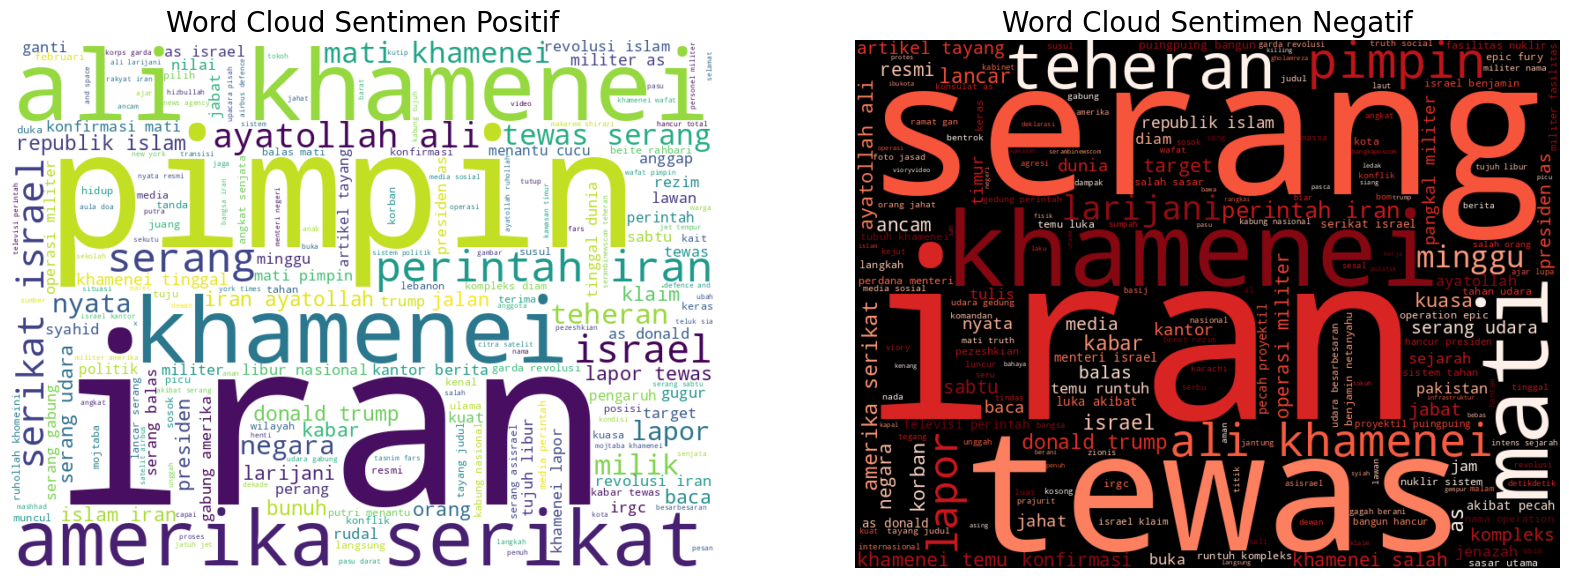

In [17]:
positive_articles_df = df_article[df_article['sentiment_label'] == 'Positive']
negative_articles_df = df_article[df_article['sentiment_label'] == 'Negative']

print(f"\nJumlah artikel Positif: {len(positive_articles_df)}")
print(f"Jumlah artikel Negatif: {len(negative_articles_df)}")

positive_text = ' '.join(positive_articles_df['text_final'])
negative_text = ' '.join(negative_articles_df['text_final'])

plt.figure(figsize=(20, 10))

# Word Cloud Positif
if positive_text:
    plt.subplot(1, 2, 1)
    wordcloud_positive = WordCloud(
        stopwords=list_stopwords,
        width=800,
        height=600,
        background_color='white',
        colormap='viridis'
    ).generate(positive_text)
    plt.imshow(wordcloud_positive, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Positif', fontsize=20)
    plt.axis('off')
else:
    print("Tidak ada teks positif untuk Word Cloud.")

# Word Cloud Negatif
if negative_text:
    plt.subplot(1, 2, 2)
    wordcloud_negative = WordCloud(
        stopwords=list_stopwords,
        width=800,
        height=600,
        background_color='black',
        colormap='Reds'
    ).generate(negative_text)
    plt.imshow(wordcloud_negative, interpolation='bilinear')
    plt.title('Word Cloud Sentimen Negatif', fontsize=20)
    plt.axis('off')
else:
    print("Tidak ada teks negatif untuk Word Cloud.")

plt.show()

**(7) Ekspor Hasil**

Bagian ini menyimpan DataFrame akhir yang berisi semua data, hasil preprocessing, dan sentimen ke dalam file CSV.

In [18]:
df_article.to_csv(r'analyzed_articles.csv', index=False)
print("Hasil analisis disimpan ke 'analyzed_articles.csv'")

Hasil analisis disimpan ke 'analyzed_articles.csv'


### Note:
Artikel dari Tribunnews cukup sulit untuk discrapping dikarenakan terdapat proteksi dari website tersebut. Setelah beberapakali mencoba dengan kode dan file csv yang sama, terkadang hasilnya berbeda (bisa terjadi error maupun bisa sukses).